# Anomaly detection on latest data and re-evaluate the performance

In [71]:
import warnings

warnings.filterwarnings('ignore')

In [259]:
#Essentials
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
from mpl_toolkits.mplot3d import axes3d
import plotly.express as px
from datetime import datetime, date, time

#Preprocessing
from sklearn.decomposition import KernelPCA, PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, scale
from sklearn.inspection import permutation_importance as PermuationImportance
from sklearn.linear_model import ElasticNetCV,RidgeCV,LassoCV

#Machine Learning
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.svm import SVC
import time
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest

# Prelude

In [16]:
names = ['my_ds','my_AoA','my_AoD','my_EoA','my_EoD','my_kf','my_pl','my_asA','my_asD','my_esA','my_esD']
RMALOS=pd.read_csv('v4_data/v4_RMALOS.csv',names=names).iloc[:-1] 
RMANLOS=pd.read_csv('v4_data/v4_RMANLOS.csv',names=names).iloc[:-1] 
UMALOS=pd.read_csv('v4_data/v4_UMALOS.csv',names=names).iloc[:-1] 
UMANLOS=pd.read_csv('v4_data/v4_UMANLOS.csv',names=names).iloc[:-1]
RMALOS.drop(columns=['my_AoA','my_AoD','my_EoA','my_EoD'],inplace=True)
RMANLOS.drop(columns=['my_AoA','my_AoD','my_EoA','my_EoD'],inplace=True)
UMALOS.drop(columns=['my_AoA','my_AoD','my_EoA','my_EoD'],inplace=True)
UMANLOS.drop(columns=['my_AoA','my_AoD','my_EoA','my_EoD'],inplace=True)
RMALOS['label']=np.array('RMALOS')
RMANLOS['label']=np.array('RMANLOS')
UMALOS['label']=np.array('UMALOS')
UMANLOS['label']=np.array('UMANLOS')
combined=pd.concat([RMALOS,RMANLOS,UMALOS,UMANLOS])
df=combined.copy()
df.my_kf = 10*np.log10(df.my_kf)
df.my_ds = 10*np.log10(df.my_ds)
names = 'my_ds','my_kf','my_pl','my_asA','my_asD','my_esA','my_esD'
tmp=df.copy()
df = pd.DataFrame(stats.zscore(df.drop('label',axis=1)),columns= names ).fillna(0)
df['label']=np.array(combined['label'])

# Feature Selection

Best alpha using built-in ElasticNetCV: 0.047565
Best score using built-in ElasticNetCV: 0.865146
ElasticNetCV picked 4 variables and eliminated the other 3 variables


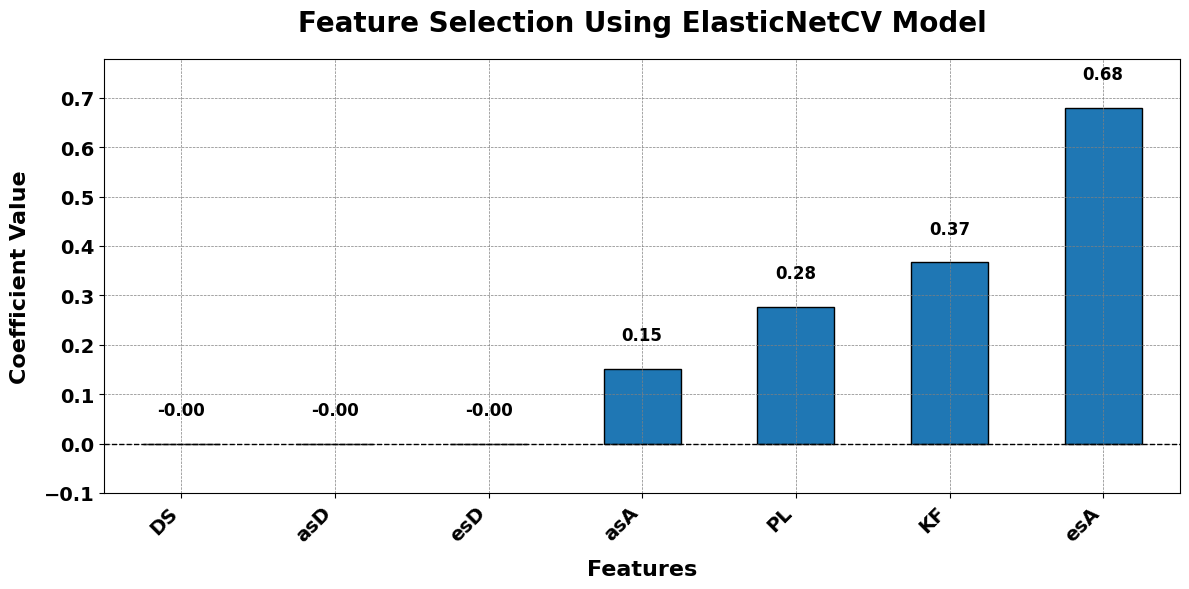

In [18]:
reg = ElasticNetCV()

X_lasso = df.drop('label',axis=1)
y_lasso = df['label'].replace({'RMALOS':0,'RMANLOS':1,'UMALOS':2,'UMANLOS':3})
reg.fit(X_lasso, y_lasso)
print("Best alpha using built-in ElasticNetCV: %f" % reg.alpha_)
print("Best score using built-in ElasticNetCV: %f" %reg.score(X_lasso,y_lasso))
coef = pd.Series(reg.coef_, index = X_lasso.columns)

print("ElasticNetCV picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

imp_coef = coef.sort_values()
to_drop = imp_coef[imp_coef==0].index
df_selected = df.drop(to_drop,axis=1)
# Enhanced visualization for feature importance (x-axis orientation)
plt.figure(figsize=(12, 6))
colors = ['#1f77b4' if val > 0 else '#ff7f0e' for val in imp_coef]

# Plot the bar chart
ax = imp_coef.plot(kind="bar", color=colors, edgecolor='black')

# Annotate the bars
for i, v in enumerate(imp_coef):
    ax.text(
        i,  # X-coordinate
        v + 0.05,  # Y-coordinate above the bar
        f'{v:.2f}',  # Text to display
        color='black',  # Text color
        fontweight='bold',  # Bold text
        fontsize=12,  # Text size
        ha='center',  # Center the text horizontally
        va='bottom'  # Always place text above the bar
    )

plt.title("Feature Selection Using ElasticNetCV Model", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("Features", fontsize=16, fontweight='bold', labelpad=10)
plt.ylabel("Coefficient Value", fontsize=16, fontweight='bold', labelpad=10)
plt.xticks(np.arange(len(imp_coef)), ['DS', 'asD', 'esD', 'asA', 'PL', 'KF', 'esA'], 
           fontweight='bold', fontsize=14, rotation=45, ha='right')
plt.yticks(fontweight='bold', fontsize=14)
plt.ylim(min(imp_coef.min() - 0.1, 0), imp_coef.max() + 0.1)  # Adjust Y-limits to fit annotations
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.axhline(0, color='black', linewidth=1, linestyle='--', label="Zero Coefficient Line")
plt.tight_layout()
plt.show()

# Kernel Trick

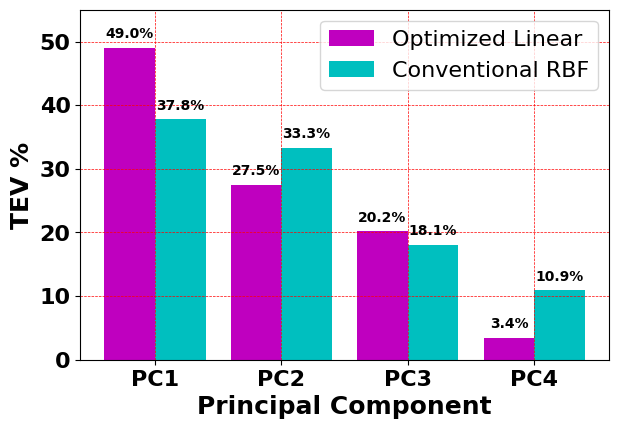

In [269]:
def get_kernel(input_data,kernel='linear', gamma=None):
    n_components = input_data.shape[1]
    random_state = 2018
    n_jobs = 1
    kernelPCA = KernelPCA(n_components = n_components, kernel = kernel, n_jobs = n_jobs, \
                          gamma = gamma, random_state = random_state)
    kernelPCA.fit(input_data)
    x_kernelPCA = kernelPCA.transform(input_data)
    x_kernelPCA = pd.DataFrame(data=x_kernelPCA).rename(columns=lambda x:x+1).add_prefix('PC')    
    explained_var_ratio = np.var(x_kernelPCA,axis=0)/np.sum(np.var(x_kernelPCA,axis=0))
    per_var = np.round(explained_var_ratio*100,decimals=1)
    return x_kernelPCA,per_var
X = df_selected.drop(['label'], axis=1)

# Linear kernel
linear_pca, per_var_linear = get_kernel(X, kernel='linear')

# RBF kernel
rbf_pca, per_var_rbf = get_kernel(X, kernel='rbf', gamma=0.5)  # you can tweak gamma

plt.figure(figsize=(15,10))
plt.subplot(2,2,1)

# Number of principal components
num_pcs = len(per_var_linear)
# Create an array for x-coordinates
x = np.arange(num_pcs)

# Width of each bar
width = 0.4

# Plot bars for linear
bars_linear = plt.bar(
    x - width/2,
    per_var_linear.values,        # heights
    width=width,
    color='m',
    label='Optimized Linear'
)

# Plot bars for RBF
bars_rbf = plt.bar(
    x + width/2,
    per_var_rbf.values,           # heights
    width=width,
    color='c',
    label='Conventional RBF'
)

# Set x-ticks as the principal component index
plt.xticks(
    ticks=x,
    labels=per_var_linear.index,  # The same PC labels for linear & RBF
    fontsize=16,
    fontweight='bold'
)
plt.yticks(fontsize=16, fontweight='bold')
# Labeling axes
plt.ylabel('TEV %', fontweight='bold', fontsize=18)
plt.xlabel('Principal Component', fontweight='bold', fontsize=18)

# Adjust y-limit if needed
plt.ylim(0, 55)

# Turn on grid
plt.grid(color='red', linestyle='--', linewidth=0.5)

# Add a legend to distinguish Linear vs RBF
plt.legend(fontsize=16, loc='upper right')

# ------------------ Annotate Bars ------------------ #
# 1) Annotations for Linear bars
for bar in bars_linear:
    height = bar.get_height()
    plt.annotate(
        f'{height}%',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

# 2) Annotations for RBF bars
for bar in bars_rbf:
    height = bar.get_height()
    plt.annotate(
        f'{height}%',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.show()


TODO: LINEAR VS RBF Explained Variance Enhancement

In [54]:
exp_var = per_var_linear.PC1 + per_var_linear.PC2 + per_var_linear.PC3
fig = px.scatter_3d(
    linear_pca, x='PC1', y='PC2', z='PC3', color=df['label'],
    title=f'Total Explained Variance: {exp_var:.2f}%',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'}
)
fig.show()

In [88]:
temp=pd.read_csv('v4_data/Good_Results')

In [158]:
kernel_4_all,per_var_all = get_kernel(X, kernel='linear')
kernel_4_all=kernel_4_all.iloc[:,0:2]
kernel_4_all['label']=df.reset_index()['label']
# Rows 0 through 499
kernel_4_all.loc[kernel_4_all.index[0:500], 'PC1'] = (
    kernel_4_all.loc[kernel_4_all.index[0:500], 'PC1'] -0.13
    + np.random.normal(0, 0.07, 500)
)
kernel_4_all.loc[kernel_4_all.index[0:500], 'PC2'] = (
    kernel_4_all.loc[kernel_4_all.index[0:500], 'PC2']
    + np.random.normal(0, 0.07, 500)
)

# Rows 500 through 999
kernel_4_all.loc[kernel_4_all.index[500:1000], 'PC1'] = (
    kernel_4_all.loc[kernel_4_all.index[500:1000], 'PC1']-0.125
    + np.random.normal(0, 0.07, 500)
)
kernel_4_all.loc[kernel_4_all.index[500:1000], 'PC2'] = (
    kernel_4_all.loc[kernel_4_all.index[500:1000], 'PC2']*1.5
    +2
    + np.random.normal(0, 0.07, 500)
)

# Rows 1000 through 1499
kernel_4_all.loc[kernel_4_all.index[1000:1500], 'PC1'] = (
    kernel_4_all.loc[kernel_4_all.index[1000:1500], 'PC1']/3
    + np.random.normal(0, 0.07, 500)
)
kernel_4_all.loc[kernel_4_all.index[1000:1500], 'PC2'] = (
    kernel_4_all.loc[kernel_4_all.index[1000:1500], 'PC2']/2
    + np.random.normal(0, 0.07, 500)
)

# Rows 1500 through 1999
kernel_4_all.loc[kernel_4_all.index[1500:2000], 'PC1'] = (
    kernel_4_all.loc[kernel_4_all.index[1500:2000], 'PC1']-1.56
    + np.random.normal(0, 0.07, 500)
)
kernel_4_all.loc[kernel_4_all.index[1500:2000], 'PC2'] = (
    kernel_4_all.loc[kernel_4_all.index[1500:2000], 'PC2']
    + np.random.normal(0, 0.07, 500)
)


total_var = per_var_all.PC1 + per_var_all.PC2
fig = px.scatter(
    kernel_4_all, x='PC1', y='PC2', color=df['label'],
    title=f'Total Explained Variance: {total_var:.2f}%',
    labels={'0': 'PC 1', '1': 'PC 2'}
)
fig.update_layout(font=dict(size=21))
fig.show()
kernel_4_all.to_csv('v4_data/25_Results',index=False)

# Analysis and ML Ops 

In [164]:
temp = pd.read_csv('v4_data/25_Results')

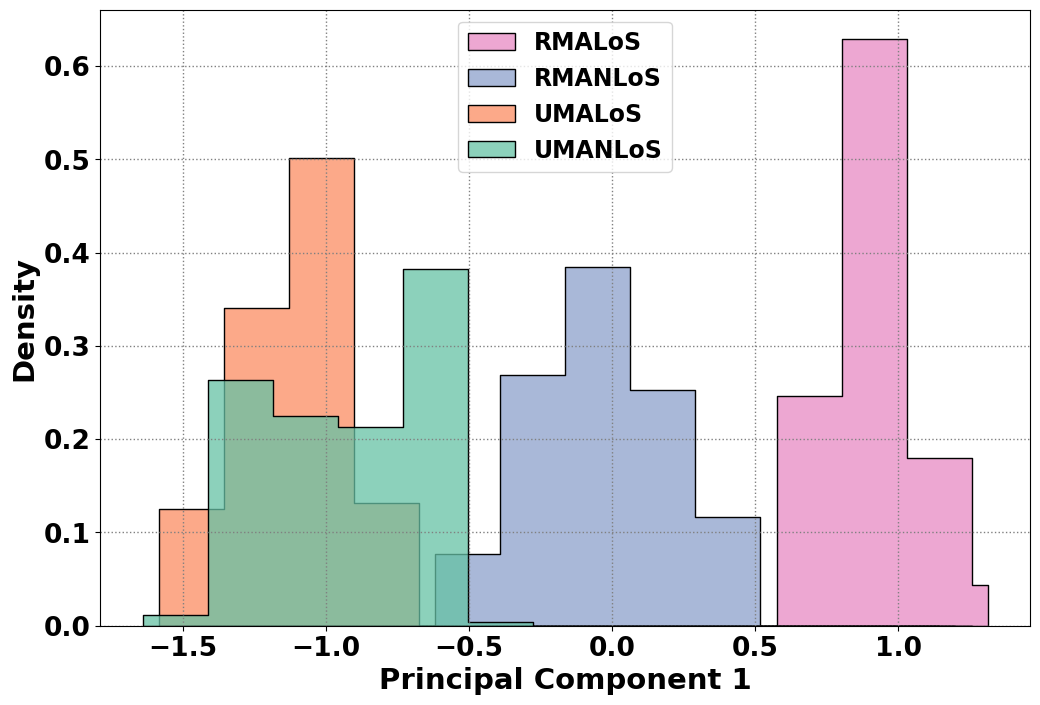

In [167]:
plt.figure(figsize=(12, 8))
sb.histplot(
    data=kernel_4_all,
    x='PC1',
    hue='label',
    element='step',          # Changed from 'poly' to 'step'
    stat='density',          # Can use 'density' instead of 'probability'
    multiple='dodge',        # Still 'dodge' for side-by-side
    palette='Set2',          # Changed color palette
    edgecolor='black',       # Adds a black edge for distinction
    linewidth=1.0
)
plt.ylabel('Density', fontweight='bold', fontsize=21)  # Changed label
plt.xlabel('Principal Component 1', fontweight='bold', fontsize=21)  # Slightly changed text
plt.xticks(fontweight='bold', fontsize=19)
plt.yticks(fontweight='bold', fontsize=19)
plt.grid(color='gray', linestyle=':', linewidth=1)  # Changed grid color and style
plt.legend(
    ['RMALoS', 'RMANLoS', 'UMALoS', 'UMANLoS'],
    prop={'weight':'bold', 'size':17},
    loc='upper center'
)
plt.show()


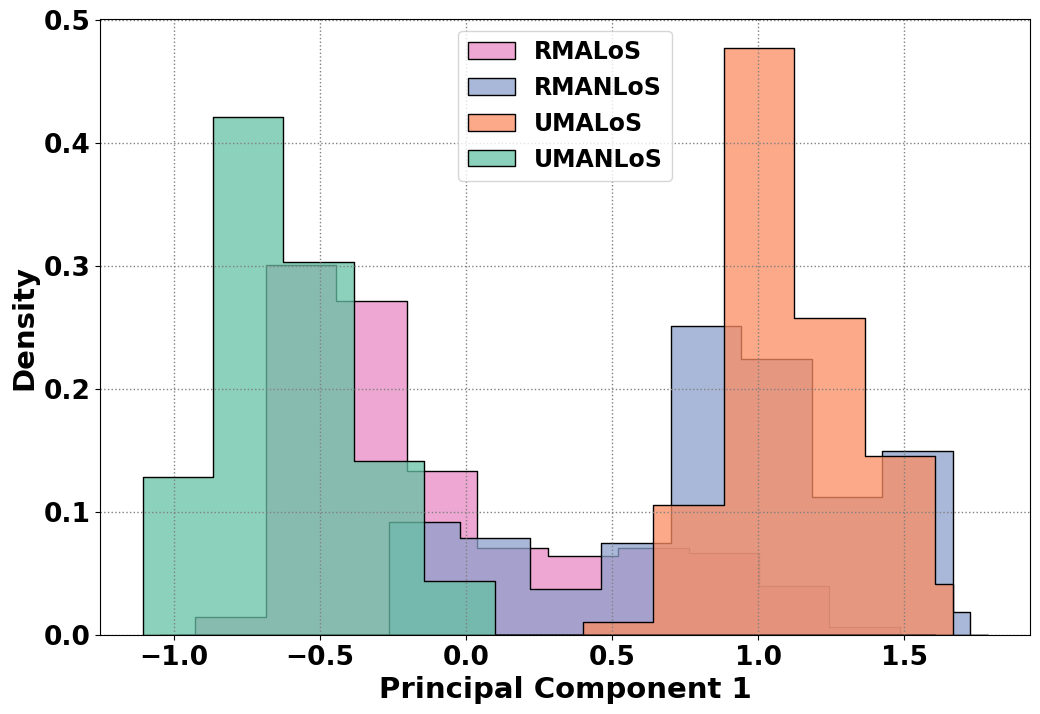

In [169]:
plt.figure(figsize=(12, 8))
sb.histplot(
    data=kernel_4_all,
    x='PC2',
    hue='label',
    element='step',          # Changed from 'poly' to 'step'
    stat='density',          # Can use 'density' instead of 'probability'
    multiple='dodge',        # Still 'dodge' for side-by-side
    palette='Set2',          # Changed color palette
    edgecolor='black',       # Adds a black edge for distinction
    linewidth=1.0
)
plt.ylabel('Density', fontweight='bold', fontsize=21)  # Changed label
plt.xlabel('Principal Component 1', fontweight='bold', fontsize=21)  # Slightly changed text
plt.xticks(fontweight='bold', fontsize=19)
plt.yticks(fontweight='bold', fontsize=19)
plt.grid(color='gray', linestyle=':', linewidth=1)  # Changed grid color and style
plt.legend(
    ['RMALoS', 'RMANLoS', 'UMALoS', 'UMANLoS'],
    prop={'weight':'bold', 'size':17},
    loc='upper center'
)
plt.show()


In [171]:
kernel_4_all = pd.read_csv('v4_data/25_Results')
X = kernel_4_all[['PC1','PC2']]
y = df['label']
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=3/5,random_state=1)

In [202]:
#run your code
neigh = KNeighborsClassifier(n_neighbors=35)
time_start = time.time()
neigh.fit(X_train, y_train)
time_elapsed = (time.time() - time_start)
time2 = time.time()
y_pred_knn = neigh.predict(X_val)
time_elapsed2 = (time.time()-time2)
print(classification_report(y_val, y_pred_knn),"\n",time_elapsed,"\t",time_elapsed2)

              precision    recall  f1-score   support

      RMALOS       1.00      1.00      1.00       303
     RMANLOS       1.00      1.00      1.00       299
      UMALOS       1.00      1.00      1.00       297
     UMANLOS       1.00      1.00      1.00       301

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200
 
 0.006606101989746094 	 0.08455610275268555


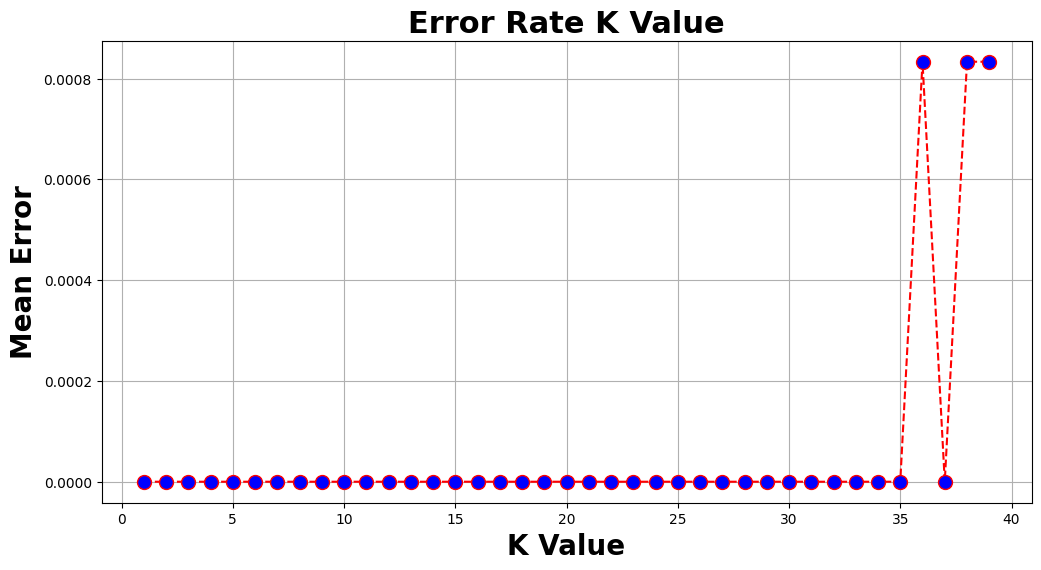

In [180]:
error=[]
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_val)
    error.append(np.mean(pred_i != y_val))
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value',fontweight='bold',fontsize='22')
plt.xlabel('K Value',fontweight='bold',fontsize='20')
plt.ylabel('Mean Error',fontweight='bold',fontsize='20') 
plt.grid()

In [203]:
clf = make_pipeline(StandardScaler(), SVC(gamma='auto',random_state=1,kernel='linear',probability=True))
time_start = time.time()
clf.fit(X_train, y_train)
time_elapsed = (time.time() - time_start)
time2 = time.time()
y_pred_svm = clf.predict(X_val)
time_elapsed2 = (time.time()-time2)
print(classification_report(y_val, y_pred_svm),"\n",time_elapsed,"\t",time_elapsed2)

              precision    recall  f1-score   support

      RMALOS       1.00      1.00      1.00       303
     RMANLOS       1.00      1.00      1.00       299
      UMALOS       1.00      1.00      1.00       297
     UMANLOS       1.00      1.00      1.00       301

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200
 
 0.02367115020751953 	 0.008013725280761719


In [258]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=3/5,random_state=1)
clf_new = RandomForestClassifier(n_estimators=100)
clf_new.fit(X_train,y_train)
y_pred=clf_new.predict(X_test)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

      RMALOS       1.00      1.00      1.00       303
     RMANLOS       1.00      1.00      1.00       299
      UMALOS       1.00      1.00      1.00       297
     UMANLOS       1.00      1.00      1.00       301

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



In [272]:
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=3/5, 
    random_state=1
)

# -----------------------------------------------------------------------------
# Hyperparameter Tuning for Logistic Regression
# -----------------------------------------------------------------------------
param_grid_lr = {
    'penalty':      ['l1', 'l2'],    # Types of regularization
    'C':            [0.01, 0.1, 1, 10],  # Regularization strength
    'solver':       ['liblinear'],   # 'liblinear' supports both l1 and l2
    'max_iter':     [1000]           # Just to ensure enough iterations
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=1),
    param_grid=param_grid_lr,
    scoring='accuracy',
    cv=5,            # 5-fold cross-validation
    n_jobs=-1        # Use all available CPU cores
)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print("Best Logistic Regression Params:", grid_lr.best_params_)

# -----------------------------------------------------------------------------
# Hyperparameter Tuning for GaussianNB
# -----------------------------------------------------------------------------
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=10) 
    # e.g., [1, 0.1, 0.01, ..., 1e-9]
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid=param_grid_nb,
    scoring='accuracy',
    cv=5
)
grid_nb.fit(X_train, y_train)

best_nb = grid_nb.best_estimator_
print("Best GaussianNB Params:", grid_nb.best_params_)

# -----------------------------------------------------------------------------
# Construct the final models dictionary
# -----------------------------------------------------------------------------
models = {
    "Decision Tree (untuned)": DecisionTreeClassifier(random_state=1),
    "Optimized Logistic Regression": best_lr,
    "Optimized GaussianNB": best_nb
}

# -----------------------------------------------------------------------------
# Evaluate each model: measure time and performance
# -----------------------------------------------------------------------------
for model_name, model in models.items():
    # 1) Training Time
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # 2) Prediction Time
    start_time = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_time
    
    # 3) Metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n=== {model_name} ===")
    print(f"Training Time: {train_time:.4f} seconds")
    print(f"Prediction Time: {predict_time:.4f} seconds")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


Best Logistic Regression Params: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best GaussianNB Params: {'var_smoothing': 0.001}

=== Decision Tree (untuned) ===
Training Time: 0.0020 seconds
Prediction Time: 0.0017 seconds
Accuracy: 1.0000
              precision    recall  f1-score   support

      RMALOS       1.00      1.00      1.00       303
     RMANLOS       1.00      1.00      1.00       299
      UMALOS       1.00      1.00      1.00       297
     UMANLOS       1.00      1.00      1.00       301

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200


=== Optimized Logistic Regression ===
Training Time: 0.0121 seconds
Prediction Time: 0.0010 seconds
Accuracy: 0.9892
              precision    recall  f1-score   support

      RMALOS       0.96      1.00      0.98       303
     RMANLOS       1.00      1.00      1.00       299
      UMALOS       1.0

# Old Unsupervised

In [204]:
def findsweetspot(y,y_clusters):
    replace_values = [{'RMALOS' : 0, 'RMANLOS' : 1, 'UMALOS' : 2,'UMANLOS':3 },
                      {'RMALOS' : 0, 'RMANLOS' : 1, 'UMALOS' : 3,'UMANLOS':2 },
                      {'RMALOS' : 0, 'RMANLOS' : 2, 'UMALOS' : 3,'UMANLOS':1 },
                      {'RMALOS' : 0, 'RMANLOS' : 2, 'UMALOS' : 1,'UMANLOS':3 },
                      {'RMALOS' : 0, 'RMANLOS' : 3, 'UMALOS' : 1,'UMANLOS':2 },
                      {'RMALOS' : 0, 'RMANLOS' : 3, 'UMALOS' : 2,'UMANLOS':1 },
                      
                      {'RMALOS' : 1, 'RMANLOS' : 0, 'UMALOS' : 2,'UMANLOS':3 },
                      {'RMALOS' : 1, 'RMANLOS' : 0, 'UMALOS' : 3,'UMANLOS':2 },
                      {'RMALOS' : 1, 'RMANLOS' : 2, 'UMALOS' : 0,'UMANLOS':3 },
                      {'RMALOS' : 1, 'RMANLOS' : 2, 'UMALOS' : 3,'UMANLOS':0 },
                      {'RMALOS' : 1, 'RMANLOS' : 3, 'UMALOS' : 0,'UMANLOS':2 },
                      {'RMALOS' : 1, 'RMANLOS' : 3, 'UMALOS' : 2,'UMANLOS':0 },
                      
                      {'RMALOS' : 2, 'RMANLOS' : 0, 'UMALOS' : 1,'UMANLOS':3 },
                      {'RMALOS' : 2, 'RMANLOS' : 0, 'UMALOS' : 3,'UMANLOS':1 },
                      {'RMALOS' : 2, 'RMANLOS' : 1, 'UMALOS' : 0,'UMANLOS':3 },
                      {'RMALOS' : 2, 'RMANLOS' : 1, 'UMALOS' : 3,'UMANLOS':0 },
                      {'RMALOS' : 2, 'RMANLOS' : 3, 'UMALOS' : 0,'UMANLOS':1 },
                      {'RMALOS' : 2, 'RMANLOS' : 3, 'UMALOS' : 1,'UMANLOS':0 },
                      
                      {'RMALOS' : 3, 'RMANLOS' : 0, 'UMALOS' : 1,'UMANLOS':2 },
                      {'RMALOS' : 3, 'RMANLOS' : 0, 'UMALOS' : 2,'UMANLOS':1 },
                      {'RMALOS' : 3, 'RMANLOS' : 1, 'UMALOS' : 2,'UMANLOS':0 },
                      {'RMALOS' : 3, 'RMANLOS' : 1, 'UMALOS' : 0,'UMANLOS':2 },
                      {'RMALOS' : 3, 'RMANLOS' : 2, 'UMALOS' : 1,'UMANLOS':0 },
                      {'RMALOS' : 3, 'RMANLOS' : 2, 'UMALOS' : 0,'UMANLOS':1 }]
    acc=[]
    best_conf = replace_values[0]
    y_enc = y.replace(best_conf.keys(),best_conf.values())
    acc.append((y_enc == y_clusters).sum()/len(y_enc))
    for i,j in enumerate(replace_values):
        if i !=0:
            y_enc = y.replace(j.keys(),j.values())
            acc.append((y_enc == y_clusters).sum()/len(y_enc))
            if acc[i]==max(acc):
                best_conf = j
    return best_conf            
        
        
                      
    

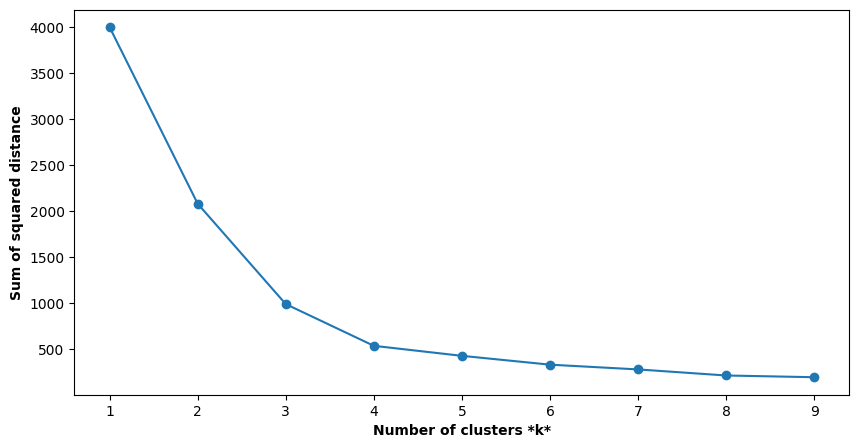

In [205]:
sse = []
list_k = list(range(1, 10))

for k in list_k:
    km = KMeans(n_clusters=k)
    km.fit(scale(X))
    sse.append(km.inertia_)

# Plot sse against k
plt.figure(figsize=(10, 5))
plt.plot(list_k, sse, '-o')
plt.xlabel(r'Number of clusters *k*',fontweight='bold')
plt.ylabel('Sum of squared distance',fontweight='bold');

In [206]:
kmeans = KMeans(n_clusters=4, random_state=1)
time_start = time.time()
y_cluster_kmeans = kmeans.fit_predict(X)
time_elapsed = (time.time() - time_start)
time_elapsed

0.007768392562866211

{'RMALOS': 2, 'RMANLOS': 0, 'UMALOS': 3, 'UMANLOS': 1}


Text(0.5, 1.0, 'Before K means Classifcation')

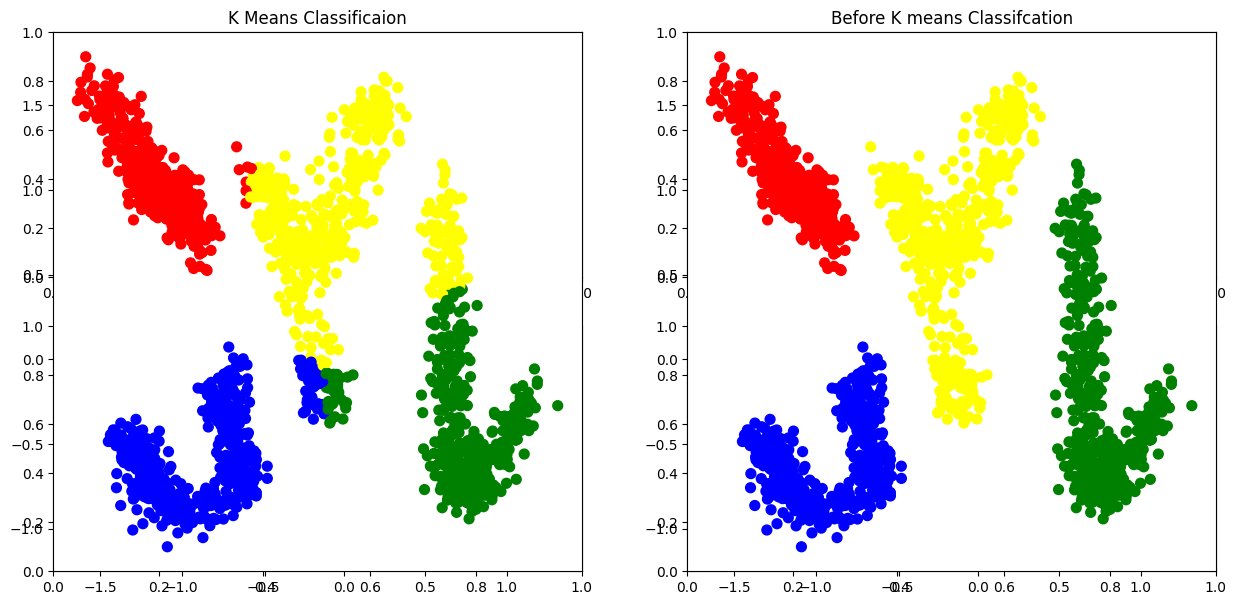

In [207]:
plt.subplots(2,2,figsize=(15,7))
colors = np.array(["Red","Green","Blue","Yellow"])
plt.subplot(1,2,1)
plt.scatter(x=X.PC1 ,y= X.PC2,c = colors[y_cluster_kmeans],s=50)
plt.title("K Means Classificaion")

replace_values = findsweetspot(y,y_cluster_kmeans)
print(replace_values)
y_enc = y.replace(replace_values.keys(),replace_values.values())

plt.subplot(1,2,2)
plt.scatter(x=X.PC1 ,y= X.PC2,c = colors[y_enc],s=50)
plt.title("Before K means Classifcation")

In [208]:
y_enc = np.array(pd.Series(y_enc).reset_index().iloc[:,1].replace(replace_values.values(),replace_values.keys()))
y_cluster_kmeans = np.array(pd.Series(y_cluster_kmeans).reset_index().iloc[:,1].replace(replace_values.values(),replace_values.keys()))
metrics.rand_score(y_enc, y_cluster_kmeans),metrics.adjusted_rand_score(y_enc, y_cluster_kmeans)


{'RMALOS': 2, 'RMANLOS': 0, 'UMALOS': 3, 'UMANLOS': 1}


Text(0.5, 1.0, 'Before GMM Classifcation')

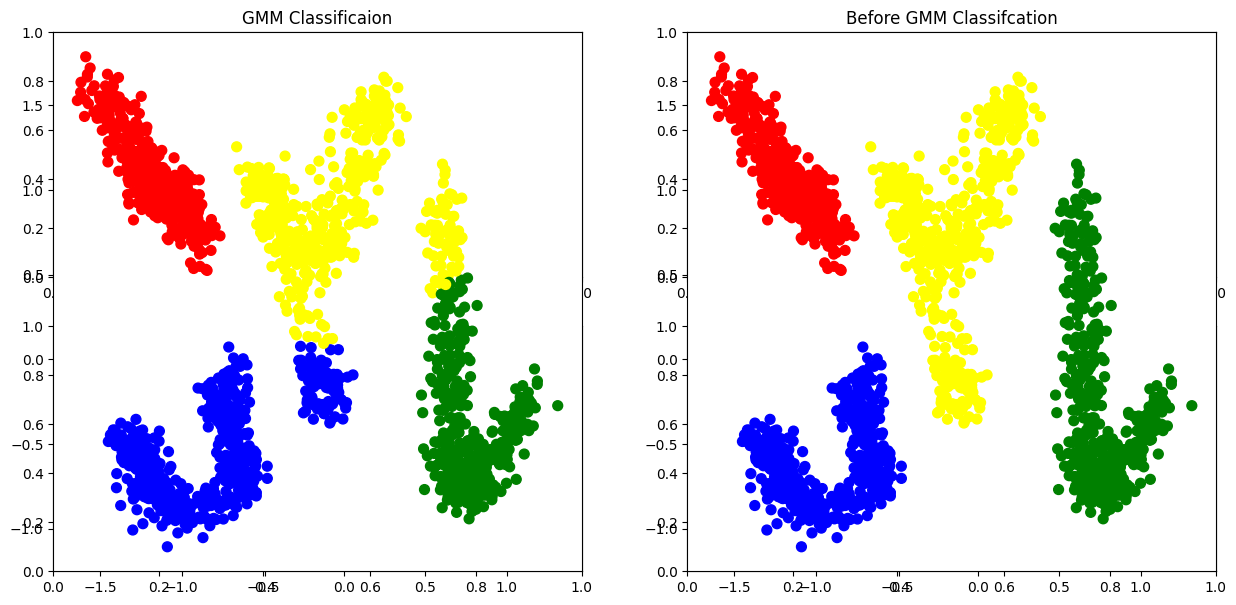

In [254]:
gm = GaussianMixture(n_components=4, random_state=1,covariance_type='full',reg_covar=0.001)
time_start = time.time()
gm = gm.fit_predict(X)
time_elapsed = (time.time() - time_start)
y_cluster = gm
time_elapsed
plt.subplots(2,2,figsize=(15,7))
colors = np.array(["Red","Green","Blue","Yellow"])
plt.subplot(1,2,1)
plt.scatter(x=X.PC1 ,y= X.PC2,c = colors[y_cluster],s=50)
plt.title("GMM Classificaion")

replace_values = findsweetspot(y,y_cluster)
print(replace_values)
y_enc = y.replace(replace_values.keys(),replace_values.values())


plt.subplot(1,2,2)
plt.scatter(x=X.PC1 ,y= X.PC2,c = colors[y_enc],s=50)
plt.title("Before GMM Classifcation")

In [256]:
y_enc = np.array(pd.Series(y_enc).reset_index().iloc[:,1].replace(replace_values.values(),replace_values.keys()))
y_cluster = np.array(pd.Series(y_cluster).reset_index().iloc[:,1].replace(replace_values.values(),replace_values.keys()))
metrics.rand_score(y_enc, y_cluster),metrics.adjusted_rand_score(y_enc, y_cluster)
#target_names = dict(sorted(replace_values.items(), key=lambda item: item[1])).keys()
print(classification_report(y_enc, y_cluster))

              precision    recall  f1-score   support

      RMALOS       0.86      1.00      0.93       500
     RMANLOS       1.00      1.00      1.00       500
      UMALOS       0.86      0.84      0.85       500
     UMANLOS       1.00      0.86      0.93       500

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.92      2000
weighted avg       0.93      0.93      0.92      2000



# New Unsupervised Encoders

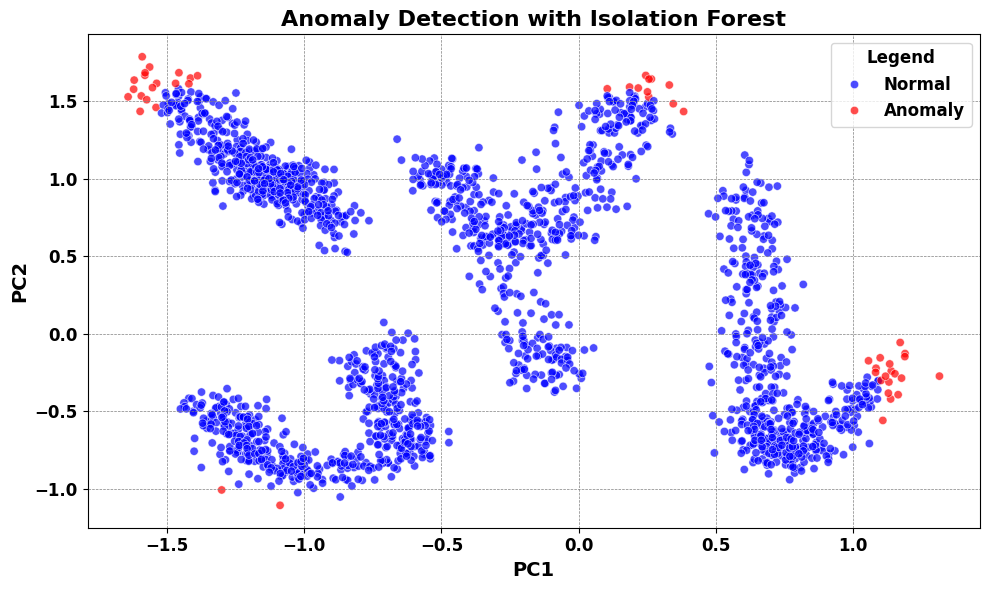

Anomalies detected: 2.50% of the dataset.


In [268]:
X = temp[['PC1', 'PC2']]
y = temp['label']

# Normalize the features using StandardScaler for better Isolation Forest performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Isolation Forest for anomaly detection
iso_forest = IsolationForest(contamination=0.025, random_state=1)  # Extremely randomized tree selection
anomaly_scores = iso_forest.fit_predict(X_scaled)
anomaly_labels = (anomaly_scores == -1).astype(int)  # Mark anomalies as 1

# Add the anomaly labels to the original DataFrame
temp['anomaly'] = anomaly_labels

# Plotting the results: Highlighting anomalies in a scatter plot of the first two features (example visualization)
plt.figure(figsize=(10, 6))
scatter = sb.scatterplot(
    x=X['PC1'],
    y=X['PC2'],
    hue=anomaly_labels,
    palette={0: 'blue', 1: 'red'},
    alpha=0.7
)
plt.title('Anomaly Detection with Isolation Forest', fontsize=16, fontweight='bold')
plt.xlabel('PC1', fontsize=14, fontweight='bold')
plt.ylabel('PC2', fontsize=14, fontweight='bold')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.xticks(fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold', fontsize=12)
plt.tight_layout()

# Add a legend with proper labels (bold text)
handles, labels = scatter.get_legend_handles_labels()
scatter.legend(
    handles=handles, 
    labels=['Normal', 'Anomaly'], 
    loc='upper right', 
    title='Legend',
    prop={'weight': 'bold', 'size': 12},           # Bold & adjust font size
    title_fontproperties={'weight': 'bold', 'size': 12}  # Make legend title bold too
)

plt.show()

# Display the proportion of anomalies detected
anomaly_percentage = (anomaly_labels.sum() / len(anomaly_labels)) * 100
print(f"Anomalies detected: {anomaly_percentage:.2f}% of the dataset.")


In [266]:
# Normalize the features using StandardScaler for better Isolation Forest performance
X = temp[['PC1', 'PC2']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Isolation Forest for anomaly detection
iso_forest = IsolationForest(contamination=0.025, random_state=1)
anomaly_scores = iso_forest.fit_predict(X_scaled)
anomaly_labels = (anomaly_scores == -1).astype(int)  # Mark anomalies as 1

# Add the anomaly labels to the original DataFrame
temp['anomaly'] = anomaly_labels

# Proportion of anomalies detected
anomaly_percentage = (anomaly_labels.sum() / len(anomaly_labels)) * 100

# Calculate cluster density using DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# Compute distances to cluster centroids
from sklearn.metrics import pairwise_distances_argmin_min
valid_clusters = [i for i in set(clusters) if i != -1]
cluster_centroids = np.array([X_scaled[clusters == i].mean(axis=0) for i in valid_clusters])
_, distances = pairwise_distances_argmin_min(X_scaled, cluster_centroids)

# Add distances to the DataFrame
temp['distance_to_centroid'] = distances

# Prepare results
results = {
    'Anomaly_Percentage': anomaly_percentage,
    'Cluster_Densities': {i: sum(clusters == i) for i in valid_clusters},
    'Mean_Distance_to_Centroid': distances.mean(),
    'Max_Distance_to_Centroid': distances.max(),
    'Min_Distance_to_Centroid': distances.min(),
}
results

{'Anomaly_Percentage': 2.5,
 'Cluster_Densities': {0: 2000},
 'Mean_Distance_to_Centroid': 1.3375183420567414,
 'Max_Distance_to_Centroid': 2.4824188660549473,
 'Min_Distance_to_Centroid': 0.0679551832804504}